EY DAY 1 – UNSOLVED HANDS-ON ASSIGNMENT

Scenario-Based Enterprise Data Analysis

Python Refresher • NumPy • Pandas • Data Types • Data Collection & Storage • Matplotlib • Seaborn • Visual Story

DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

training = pd.DataFrame({
    "employee_id": [
        "EY101","EY102","EY103","EY104","EY105",
        "EY106","EY107","EY108","EY109","EY110",
        "EY111","EY112"
    ],
    "department": [
        "AI","Cloud","Data","AI","Cloud",
        "Data","AI","Cloud","Data","AI",
        "Cloud","Data"
    ],
    "training_hours": [
        32,24,40,18,30,26,44,20,36,28,22,34
    ],
    "attendance": [
        96,82,98,65,91,88,97,72,94,85,76,90
    ],
    "assessment_score": [
        86,68,94,52,79,72,91,61,88,75,64,81
    ],
    "experience_years": [
        1,0,2,1,3,0,2,1,4,2,0,3
    ],
    "status": [
        "Completed","Completed","Completed","Incomplete",
        "Completed","Completed","Completed","Incomplete",
        "Completed","Completed","Incomplete","Completed"
    ]
})

training

,employee_id,department,training_hours,attendance,assessment_score,experience_years,status
0,EY101,AI,32,96,86,1,Completed
1,EY102,Cloud,24,82,68,0,Completed
2,EY103,Data,40,98,94,2,Completed
3,EY104,AI,18,65,52,1,Incomplete
4,EY105,Cloud,30,91,79,3,Completed
5,EY106,Data,26,88,72,0,Completed
6,EY107,AI,44,97,91,2,Completed
7,EY108,Cloud,20,72,61,1,Incomplete
8,EY109,Data,36,94,88,4,Completed
9,EY110,AI,28,85,75,2,Completed


 Part A – Data Understanding


In [2]:
#11. Display the first five records.
training.head(5)

,employee_id,department,training_hours,attendance,assessment_score,experience_years,status
0,EY101,AI,32,96,86,1,Completed
1,EY102,Cloud,24,82,68,0,Completed
2,EY103,Data,40,98,94,2,Completed
3,EY104,AI,18,65,52,1,Incomplete
4,EY105,Cloud,30,91,79,3,Completed


In [3]:
#12. Find the number of rows and columns.
training.shape

(12, 7)

In [4]:
#13. Display all column names.
print(training.columns)

Index(['employee_id', 'department', 'training_hours', 'attendance',
       'assessment_score', 'experience_years', 'status'],
      dtype='object')


In [5]:
#14. Display the data types of all columns.
print(training.dtypes)

employee_id         object
department          object
training_hours       int64
attendance           int64
assessment_score     int64
experience_years     int64
status              object
dtype: object


In [6]:
#15. Generate descriptive statistics for the numerical columns.
print(training.describe())


       training_hours  attendance  assessment_score  experience_years
count       12.000000   12.000000         12.000000         12.000000
mean        29.500000   86.166667         75.916667          1.583333
std          8.050974   10.564377         12.978712          1.311372
min         18.000000   65.000000         52.000000          0.000000
25%         23.500000   80.500000         67.000000          0.750000
50%         29.000000   89.000000         77.000000          1.500000
75%         34.500000   94.500000         86.500000          2.250000
max         44.000000   98.000000         94.000000          4.000000


In [7]:
#16. Check whether there are missing values.
print(training.isnull().sum())

employee_id         0
department          0
training_hours      0
attendance          0
assessment_score    0
experience_years    0
status              0
dtype: int64


Thus no missing values

In [8]:
#17. Identify the unique departments
print(training['department'].unique())

['AI' 'Cloud' 'Data']


In [9]:
#18. Identify the unique training status values.
print(training['status'].unique())

['Completed' 'Incomplete']


 Part B – NumPy Challenge

In [10]:
#19. Create a NumPy array containing all assessment scores.
assessment_scores = np.array(training['assessment_score'])
print(assessment_scores)

[86 68 94 52 79 72 91 61 88 75 64 81]


In [11]:
#20. Calculate the average score.
average_score = np.mean(assessment_scores)
print(average_score)

75.91666666666667


In [12]:
#21. Find the highest score.
highest_score = np.max(assessment_scores)
print(highest_score)

94


In [13]:
#22. Find the lowest score.
lowest_score = np.min(assessment_scores)
print(lowest_score)

52


In [14]:
#23. Identify scores above or equal to 80.
above_80 = assessment_scores[assessment_scores >= 80]
print(above_80)
#

[86 94 91 88 81]


In [15]:
#24. Identify scores below 70.
below_70 = assessment_scores[assessment_scores < 70]
print(below_70)
#

[68 52 61 64]


In [16]:
#25. Calculate the average attendance using a NumPy array.
average_attendance = np.mean(training['attendance'])
print(average_attendance)
#

86.16666666666667


 Part C – Pandas DataFrame Analysis


In [17]:
'''Task 1 – Column selection
Select only:
• employee_id and department
• employee_id and assessment_score
• department, attendance and assessment_score'''

print(training[['employee_id', 'department']])
print("-"*80)
print(training[['employee_id', 'assessment_score']])
print("-"*80)
print(training[['department', 'attendance', 'assessment_score']])


   employee_id department
0        EY101         AI
1        EY102      Cloud
2        EY103       Data
3        EY104         AI
4        EY105      Cloud
5        EY106       Data
6        EY107         AI
7        EY108      Cloud
8        EY109       Data
9        EY110         AI
10       EY111      Cloud
11       EY112       Data
--------------------------------------------------------------------------------
   employee_id  assessment_score
0        EY101                86
1        EY102                68
2        EY103                94
3        EY104                52
4        EY105                79
5        EY106                72
6        EY107                91
7        EY108                61
8        EY109                88
9        EY110                75
10       EY111                64
11       EY112                81
--------------------------------------------------------------------------------
   department  attendance  assessment_score
0          AI          96  

In [18]:
'''Task 2 – High performers
Create a filtered DataFrame containing employees who meet BOTH of the following exercise criteria:
• Assessment score is greater than or equal to 85.
• Attendance is greater than or equal to 90.'''
High_performers = training[(training['assessment_score'] >= 85) & (training['attendance'] >= 90)]
print(High_performers)


  employee_id department  training_hours  attendance  assessment_score  \
0       EY101         AI              32          96                86   
2       EY103       Data              40          98                94   
6       EY107         AI              44          97                91   
8       EY109       Data              36          94                88   

   experience_years     status  
0                 1  Completed  
2                 2  Completed  
6                 2  Completed  
8                 4  Completed  


In [19]:
'''Task 3 – Employees needing attention
Create a second filtered DataFrame containing employees who meet AT LEAST ONE of the following criteria:
• Assessment score is below 70.
• Attendance is below 75. '''
Low_performers = training[(training['assessment_score'] < 70) | (training['attendance'] < 75)]
print(Low_performers)

   employee_id department  training_hours  attendance  assessment_score  \
1        EY102      Cloud              24          82                68   
3        EY104         AI              18          65                52   
7        EY108      Cloud              20          72                61   
10       EY111      Cloud              22          76                64   

    experience_years      status  
1                  0   Completed  
3                  1  Incomplete  
7                  1  Incomplete  
10                 0  Incomplete  


In [20]:
'''Task 4 – Ranking
Sort the employees by assessment score from highest to lowest and display the top five records.'''
print(training.sort_values(by='assessment_score', ascending=False).head(5))

   employee_id department  training_hours  attendance  assessment_score  \
2        EY103       Data              40          98                94   
6        EY107         AI              44          97                91   
8        EY109       Data              36          94                88   
0        EY101         AI              32          96                86   
11       EY112       Data              34          90                81   

    experience_years     status  
2                  2  Completed  
6                  2  Completed  
8                  4  Completed  
0                  1  Completed  
11                 3  Completed  


In [21]:
'''Task 5 – Department summary
Calculate the average assessment score, average attendance and average training hours for each department. '''
avg_assessment_score = training.groupby('department')['assessment_score'].mean()
avg_attendance = training.groupby('department')['attendance'].mean()
avg_training_hours = training.groupby('department')['training_hours'].mean()
print(avg_assessment_score)
print(avg_attendance)
print(avg_training_hours)


department
AI       76.00
Cloud    68.00
Data     83.75
Name: assessment_score, dtype: float64
department
AI       85.75
Cloud    80.25
Data     92.50
Name: attendance, dtype: float64
department
AI       30.5
Cloud    24.0
Data     34.0
Name: training_hours, dtype: float64


8. Part D – Data Quality Investigation

In [22]:
#26. Are there missing values?
print(training.isnull().sum())

employee_id         0
department          0
training_hours      0
attendance          0
assessment_score    0
experience_years    0
status              0
dtype: int64


Since all columns have 0 null values, no missing values exist

In [23]:
#27. Are there incomplete training records?
print(training[training['status'] == 'Incomplete']
      )

   employee_id department  training_hours  attendance  assessment_score  \
3        EY104         AI              18          65                52   
7        EY108      Cloud              20          72                61   
10       EY111      Cloud              22          76                64   

    experience_years      status  
3                  1  Incomplete  
7                  1  Incomplete  
10                 0  Incomplete  


Yes Certain Training records are incomplete.

In [24]:
#28. Are there employees with unusually low attendance?
print(training[training['attendance'] < 75].count())

employee_id         2
department          2
training_hours      2
attendance          2
assessment_score    2
experience_years    2
status              2
dtype: int64


Since count>0, yes employees with unusually low attendance exist

In [25]:
#29. Are there employees with unusually low assessment scores?
print(training[training['assessment_score'] < 60].count())

employee_id         1
department          1
training_hours      1
attendance          1
assessment_score    1
experience_years    1
status              1
dtype: int64


Yes since count>0

In [26]:
#30. Do any records require further investigation before management makes a decision?
print(training[training['attendance'] < 75].count())
print(training[training['assessment_score'] < 60].count())

employee_id         2
department          2
training_hours      2
attendance          2
assessment_score    2
experience_years    2
status              2
dtype: int64
employee_id         1
department          1
training_hours      1
attendance          1
assessment_score    1
experience_years    1
status              1
dtype: int64


Yes

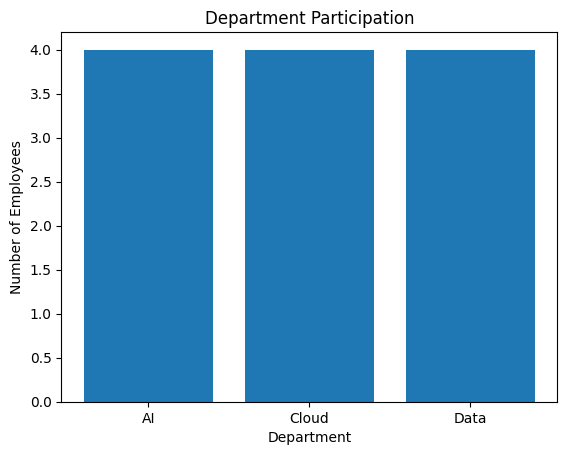

In [27]:
'''Visualization 1 – Department participation
Create a bar chart showing the number of employees in each department.
Your chart should contain:
• Meaningful title
• X-axis label
• Y-axis label
• Readable category names '''
department_counts = training['department'].value_counts()
plt.bar(department_counts.index, department_counts.values)
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.title('Department Participation')
plt.show()


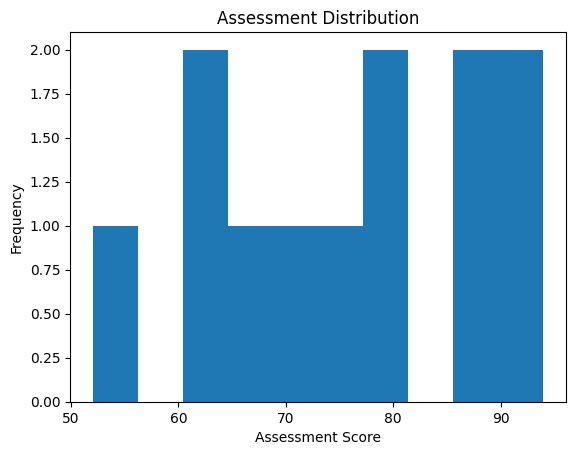

In [28]:
'''Visualization 2 – Assessment distribution
Create a histogram showing the distribution of assessment scores.'''
plt.hist(training['assessment_score'], bins=10)
plt.xlabel('Assessment Score')
plt.ylabel('Frequency')
plt.title('Assessment Distribution')
plt.show()

Overall performance follows a normal distribution

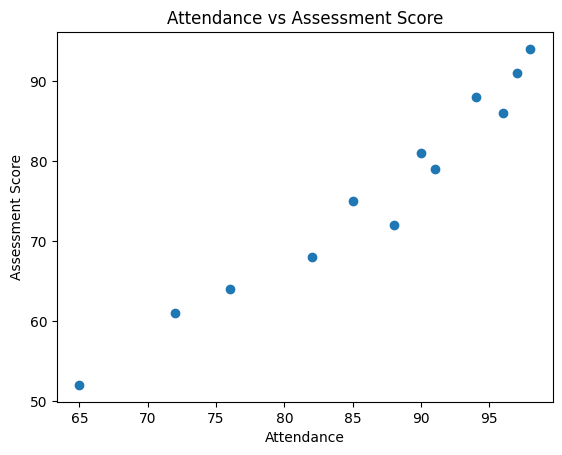

In [29]:
'''Visualization 3 – Attendance vs Assessment Score
Create a scatter plot with:
• Attendance on one axis
• Assessment score on the other axis
• Meaningful title
• Appropriate axis labels'''
plt.scatter(training['attendance'], training['assessment_score'])
plt.xlabel('Attendance')
plt.ylabel('Assessment Score')
plt.title('Attendance vs Assessment Score')
plt.show()

Apparently Attendance and Assessment score are directly correlated

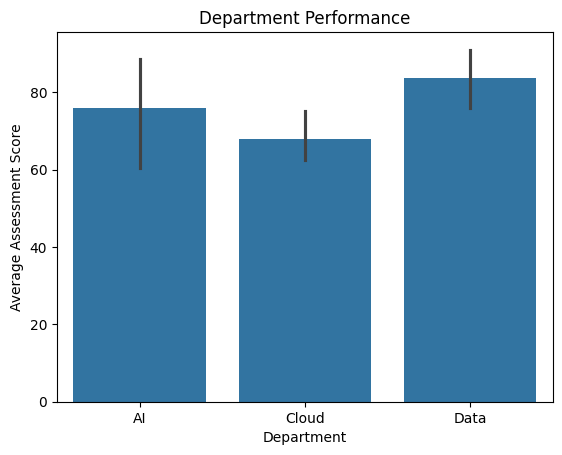

In [30]:
'''Visualization 4 – Department performance
Create a visualization comparing average assessment score across departments. You may use Matplotlib or Seaborn.
'''
sns.barplot(x='department', y='assessment_score', data=training)
plt.xlabel('Department')
plt.ylabel('Average Assessment Score')
plt.title('Department Performance')
plt.show()

10. Part F – Visual Story

31. What is the most important finding about employee performance?

It is directly proportional to training hours

32. What is the most important finding about attendance?

Average attendance for cloud is quite low

33. Is there a department-level pattern worth investigating?

Average attendance and Average assessment score for cloud is quite low

34. Which employees or records may require follow-up?

The ones with very low scores and very low attendance

35. What additional information would you request before making an intervention decision?

Any personal issues employee might be facing

36. Write three concise management-level insights.

- Cloud department is lacking
- All departments participate equally
- Need stricter attendance rules

11. Part G – Scenario Challenge

The L&D manager says: “I do not want to contact every employee who has a score below 70. Can you create a more
meaningful way to identify people who may need attention?”
Design your own rule using at least TWO variables.
Possible variables:
• Assessment score
• Attendance
• Training hours
• Experience years
• Completion status
Requirements:
37. Write your rule in plain English.
38. Translate the rule into Pandas code.
39. Show the resulting records.
40. Explain why your rule may be more useful than using assessment score alone.
41. Mention one limitation of your rule.

If person has low training hours and low experience years, they may not need intervention. Thus people with high training hours or experience still scoring low need intervention.

In [31]:
training[(training['assessment_score'] < 70) & ((training['training_hours'] > 10) | (training['experience_years'] > 1))]


,employee_id,department,training_hours,attendance,assessment_score,experience_years,status
1,EY102,Cloud,24,82,68,0,Completed
3,EY104,AI,18,65,52,1,Incomplete
7,EY108,Cloud,20,72,61,1,Incomplete
10,EY111,Cloud,22,76,64,0,Incomplete


Limitation: Does not take into consideration individual's personal issues.

12. Part H – Different Business Context Transfer

Banking: Barplot of customer ids on X- axis and Average transactions on Y axis

Retail: Groupby operation of pandas and a histogram to show distribution.

Healthcare: Group patients by department and Bar plot to compare average waiting time

Logistics: Scatterplot of delivery time Vs Customer ratings

Finance: Group by department and barplot of spendings.




13. Submission Requirements verified.

14. Self review checklist verified


15. Final Reflection

First I would present the People Performing the best to show the strongest candidates. Then show the Department wise average score, then the weakest scorers requiring intervention.

Next, I would recommend investigating if attending the training virtually or physically leads to any difference in the outcomes.